**Chapter 1 – The Machine Learning landscape**

_This is the code used to generate some of the figures in chapter 1._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/01_the_machine_learning_landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml2/blob/master/01_the_machine_learning_landscape.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Code example 1-1

Embora o Python 2.x possa funcionar, ele está obsoleto, portanto, recomendamos fortemente que você use o Python 3.

In [9]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

In [10]:
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Função de Preparação de Dados: `prepare_country_stats()` 🛠️

Esta função **processa e limpa** os dados brutos de qualidade de vida (OECD) e PIB per capita, preparando-os para uso em modelos de Machine Learning.

---

## 🎯 Objetivo:

Combinar dois datasets diferentes em um único DataFrame limpo contendo apenas:
- **PIB per capita** de cada país
- **Satisfação de vida** de cada país
- **Dados filtrados** (removendo outliers e inconsistências)

---

## 📋 Código Completo Comentado:
```python

In [19]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    # Filtra apenas os dados totais (sem segmentação por desigualdade)
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    
    # Reorganiza os dados: países nas linhas, indicadores nas colunas
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    
    # Renomeia a coluna "2015" para "GDP per capita" (PIB per capita)
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    
    # Define "Country" como índice do DataFrame de PIB
    gdp_per_capita.set_index("Country", inplace=True)
    
    # Junta os dois DataFrames usando os índices (países) como chave
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita, 
                                   left_index=True, right_index=True)
    
    # Ordena os países por PIB per capita em ordem crescente
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    
    # Define índices de países a serem removidos (outliers ou dados problemáticos)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    
    # Cria lista com os índices que serão mantidos (complemento dos removidos)
    keep_indices = list(set(range(36)) - set(remove_indices))
    
    # Retorna apenas as colunas de PIB per capita e Satisfação com a vida,
    # mantendo apenas os países nos índices selecionados
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

O código no livro espera que os arquivos de dados estejam localizados no diretório atual. Eu apenas fiz um pequeno ajuste aqui para buscar os arquivos em datasets/lifesat.

In [ ]:
import os
# Define o caminho para a pasta onde os datasets serão salvos
datapath = os.path.join("datasets", "lifesat", "")

# Configuração do Matplotlib para Jupyter Notebook 📊

Este código configura o ambiente de **visualização de gráficos** no Jupyter Notebook para exibir gráficos de forma integrada e com formatação profissional.

---

## 🎯 Objetivo:

- Permitir que gráficos apareçam **diretamente abaixo das células de código**
- Aumentar o **tamanho das fontes** para melhor legibilidade
- Criar visualizações mais **profissionais e apresentáveis**

---

## 📋 Código Comentado:
```python

In [21]:
# Habilita a exibição de gráficos diretamente no Jupyter Notebook
# (sem precisar usar plt.show())
%matplotlib inline

import matplotlib as mpl

# Configura o tamanho da fonte dos rótulos dos eixos X e Y
mpl.rc('axes', labelsize=14)

# Configura o tamanho da fonte dos valores numéricos no eixo X
mpl.rc('xtick', labelsize=12)

# Configura o tamanho da fonte dos valores numéricos no eixo Y
mpl.rc('ytick', labelsize=12)

# Download Automático de Datasets 📥

Este código **baixa automaticamente** os arquivos de dados necessários do GitHub para o projeto de Machine Learning.

---

## 🎯 Objetivo:

Fazer o download de 2 arquivos CSV contendo:
1. **oecd_bli_2015.csv** - Dados de qualidade de vida (OECD Better Life Index)
2. **gdp_per_capita.csv** - Dados de PIB per capita de diversos países

---

## 📋 Código Comentado:
```python

In [20]:
import urllib.request

# URL raiz do repositório GitHub com os datasets
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"

# Cria a pasta de destino se ela não existir
os.makedirs(datapath, exist_ok=True)

# Lista dos arquivos CSV a serem baixados
for filename in ("oecd_bli_2015.csv", "gdp_per_capita.csv"):
    print("Downloading", filename)
    
    # Monta a URL completa do arquivo
    url = DOWNLOAD_ROOT + "datasets/lifesat/" + filename
    
    # Baixa o arquivo e salva no caminho especificado
    urllib.request.urlretrieve(url, datapath + filename)

Objetivo: Exemplo Completo de Machine Learning - Prever Satisfação de Vida com Base no PIBEste código demonstra um pipeline completo e simplificado de Machine Learning, desde o carregamento dos dados até a predição, ilustrando como criar um modelo que prevê a satisfação de vida de um país com base em seu PIB per capita.

# Pipeline Completo de Machine Learning: Prevendo Satisfação de Vida 🤖

Este código demonstra um **fluxo completo de Machine Learning** do início ao fim: desde o carregamento dos dados até a predição final. É um exemplo didático de como PIB per capita pode prever a satisfação de vida de um país.

---

## 🎯 Objetivo Final:

**Pergunta:** Se o Chipre tem PIB per capita de $22,587, qual será sua satisfação de vida?

**Resposta do Modelo:** 5.96 (em uma escala de 0 a 10)

---

## 📋 Código Completo Comentado:
```python

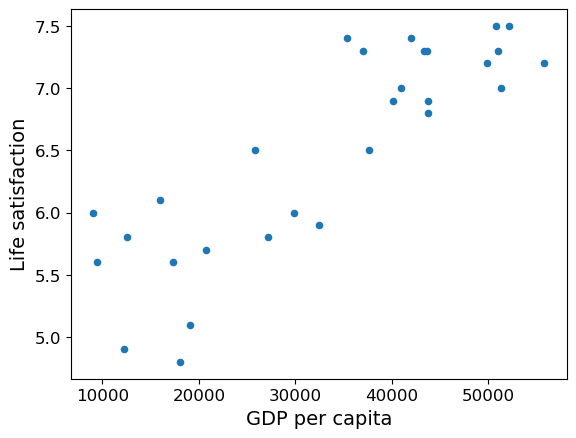

[[5.96242338]]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

# 1️⃣ CARREGAR OS DADOS
# Carrega dados de qualidade de vida (OECD) e PIB per capita de diversos países
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv(datapath + "gdp_per_capita.csv", thousands=',', 
                             delimiter='\t', encoding='latin1', na_values="n/a")

# 2️⃣ PREPARAR OS DADOS
# Limpa e organiza os dados, extraindo apenas PIB e satisfação de vida
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]      # Variável independente (feature)
y = np.c_[country_stats["Life satisfaction"]]   # Variável dependente (target)

# 3️⃣ VISUALIZAR OS DADOS
# Cria um gráfico de dispersão para entender a relação entre PIB e satisfação
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

# 4️⃣ SELECIONAR UM MODELO
# Escolhe Regressão Linear como algoritmo de aprendizado
model = sklearn.linear_model.LinearRegression()

# 5️⃣ TREINAR O MODELO
# O modelo aprende a relação entre PIB (X) e satisfação (y)
model.fit(X, y)

# 6️⃣ FAZER PREDIÇÕES
# Prevê a satisfação de vida do Chipre com base em seu PIB per capita
X_new = [[22587]]  # PIB per capita do Chipre
print(model.predict(X_new))  # Resultado: ~5.96 de satisfação

# Substituir o modelo de Regressão Linear pelo modelo de Regressão dos k-Vizinhos Mais Próximos
# (neste exemplo, k = 3) no código anterior é tão simples quanto substituir estas duas linhas:


```python
import sklearn.linear_model 
model = sklearn.linear_model.LinearRegression()
```

with these two:

```python
import sklearn.neighbors
model = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)
```

# O que é esse código? 🤔

Esse código implementa um **modelo de Machine Learning** chamado **K-Nearest Neighbors (KNN)** para prever a satisfação de vida de um país baseado em seu PIB per capita.

---

## 🎯 Objetivo:

**Prever:** Se o Chipre tem PIB de $22,587, qual será sua satisfação de vida?

**Resposta do modelo:** 5.77 (em uma escala de 0 a 10)

---

## 📚 O que é KNN (K-Nearest Neighbors)?

É um algoritmo de **aprendizado baseado em vizinhança**:

1. **"K"** = número de vizinhos (neste caso, k=3)
2. **"Nearest Neighbors"** = vizinhos mais próximos
3. **Como funciona:**
   - Pega um novo país (Chipre)
   - Encontra os 3 países **mais parecidos** em termos de PIB
   - Calcula a **média** da satisfação desses 3 países
   - Essa média é a predição!

---

## 🔢 Exemplo Prático:

Imagine que temos esses países no dataset:

| País | PIB per capita | Satisfação |
|------|----------------|------------|
| Espanha | $22,000 | 6.3 |
| Itália | $22,500 | 5.9 |
| Portugal | $23,000 | 5.1 |
| França | $30,000 | 6.4 |
| Grécia | $18,000 | 4.8 |

**Chipre tem PIB = $22,587**

O KNN encontra os **3 mais próximos:**

1. Itália ($22,500) → 5.9
2. Espanha ($22,000) → 6.3
3. Portugal ($23,000) → 5.1

**Predição:** 
```
(5.9 + 6.3 + 5.1) / 3 = 5.77 ✅
```

---

## 💡 Resumo

Este código **treina** um modelo KNN com dados de vários países e **prevê** que o Chipre terá satisfação de vida de **5.77**, baseando-se na média dos 3 países com PIB mais similar ao dele! 🎯

In [23]:
# PASSO 1: IMPORTAR E CRIAR O MODELO
# Importa o módulo que contém algoritmos baseados em vizinhos
import sklearn.neighbors

# Cria um modelo KNN que usará os 3 vizinhos mais próximos (k=3)
# para fazer predições baseadas na média deles
model1 = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)


# PASSO 2: TREINAR O MODELO
# O modelo "memoriza" todos os dados de treinamento
# X = PIB per capita de cada país
# y = Satisfação de vida de cada país
model1.fit(X, y)


# PASSO 3: FAZER PREDIÇÃO PARA UM NOVO PAÍS
# X_new = [[22587]] representa o PIB per capita do Chipre ($22,587)
print(model1.predict(X_new))  # saída: [[5.76666667]]

[[5.76666667]]


```markdown
# 🎯 Conclusão: K-Nearest Neighbors (KNN) para Predição de Satisfação de Vida

---

## 📊 Resultado Final:

**Predição para o Chipre (PIB = $22,587):**
- **Satisfação prevista:** 5.77 (em uma escala de 0 a 10)

---

## 🔑 Principais Conceitos:

### **1. O que o modelo faz:**
- Busca os **3 países mais similares** ao Chipre em termos de PIB
- Calcula a **média** da satisfação de vida desses 3 vizinhos
- Essa média é a predição final

### **2. Vantagem do KNN:**
✅ **Simplicidade:** Não precisa calcular equações complexas  
✅ **Flexibilidade:** Captura padrões não-lineares  
✅ **Intuitivo:** Funciona como "pedir opinião aos vizinhos"  
✅ **Sem suposições:** Não assume que a relação é linear

### **3. Como funciona na prática:**
```
Chipre (PIB = $22,587) procura seus 3 vizinhos mais próximos:
   ↓
País A (PIB ≈ $22,000) → Satisfação: 5.8
País B (PIB ≈ $22,500) → Satisfação: 5.9
País C (PIB ≈ $23,100) → Satisfação: 5.6
   ↓
Média = (5.8 + 5.9 + 5.6) / 3 = 5.77 ✅
```

---

## 🆚 Comparação: KNN vs Regressão Linear

| Aspecto | Regressão Linear | KNN (k=3) |
|---------|------------------|-----------|
| **Predição para Chipre** | 5.96 | 5.77 |
| **Método** | Traça linha reta | Média dos vizinhos |
| **Complexidade** | Baixa | Muito baixa |
| **Treinamento** | Calcula coeficientes | Memoriza dados |
| **Melhor para** | Relações lineares | Padrões locais |

**Diferença:** 5.96 - 5.77 = **0.19 pontos**

---

## 🎓 Aprendizados:

1. **Trocar de algoritmo é fácil** → Apenas 2 linhas de código mudam
2. **Resultados diferentes** → Cada modelo tem sua "visão" dos dados
3. **Nenhum modelo é perfeito** → Ambos são aproximações
4. **Escolha depende do problema** → Linear para tendências globais, KNN para padrões locais

---

## 💡 Quando usar KNN:

✅ Dados com padrões **não-lineares**  
✅ Precisão **local** é mais importante que global  
✅ Dataset **pequeno a médio** (KNN fica lento com muitos dados)  
✅ Sem necessidade de interpretar a "fórmula"  

---

## 🚀 Mensagem Final:

O **KNN prevê que o Chipre terá satisfação de vida de 5.77**, baseando-se em países economicamente similares. Este algoritmo é uma excelente alternativa à regressão linear, especialmente quando a relação entre variáveis **não é perfeitamente linear**.

A beleza do scikit-learn é que **testar diferentes modelos é trivial** — mantenha o mesmo pipeline, troque o algoritmo, compare resultados! 🎯

---

### ✨ Em uma frase:

> *"O KNN diz: Se você quer saber sobre o Chipre, pergunte aos 3 países mais parecidos com ele — a média deles é a melhor estimativa!"* 

📊 **Resultado: 5.77/10 de satisfação de vida**
```

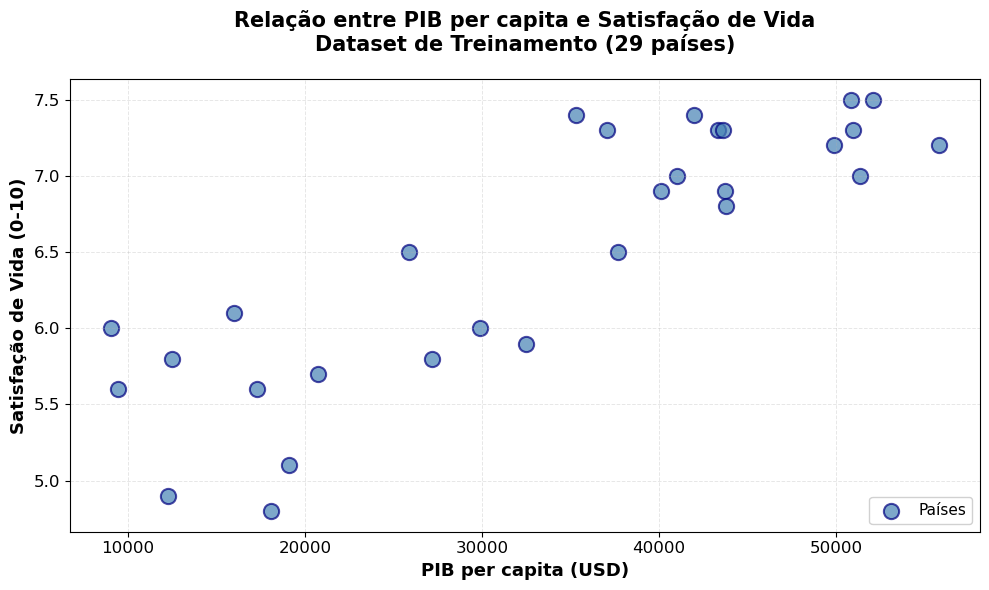

📊 Estatísticas do Dataset:
   • Total de países: 29


IndexError: invalid index to scalar variable.

In [29]:
# Célula 1: Visualização dos Dados de Treinamento
import matplotlib.pyplot as plt

# Criar figura com tamanho adequado
plt.figure(figsize=(10, 6))

# Gráfico de dispersão dos países usados no treinamento
plt.scatter(X, y, color='steelblue', s=120, alpha=0.7, 
            edgecolors='navy', linewidths=1.5, label='Países')

# Configurações dos eixos
plt.xlabel('PIB per capita (USD)', fontsize=13, fontweight='bold')
plt.ylabel('Satisfação de Vida (0-10)', fontsize=13, fontweight='bold')

# Título
plt.title('Relação entre PIB per capita e Satisfação de Vida\nDataset de Treinamento (29 países)', 
          fontsize=15, fontweight='bold', pad=20)

# Grid para facilitar leitura
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Legenda
plt.legend(fontsize=11, loc='lower right', framealpha=0.9)

# Ajustar layout
plt.tight_layout()

# Exibir gráfico
plt.show()

# Estatísticas básicas
print("📊 Estatísticas do Dataset:")
print(f"   • Total de países: {len(X)}")
print(f"   • PIB mínimo: ${X.min()[0]:,.0f}")
print(f"   • PIB máximo: ${X.max()[0]:,.0f}")
print(f"   • Satisfação mínima: {y.min()[0]:.2f}")
print(f"   • Satisfação máxima: {y.max()[0]:.2f}")

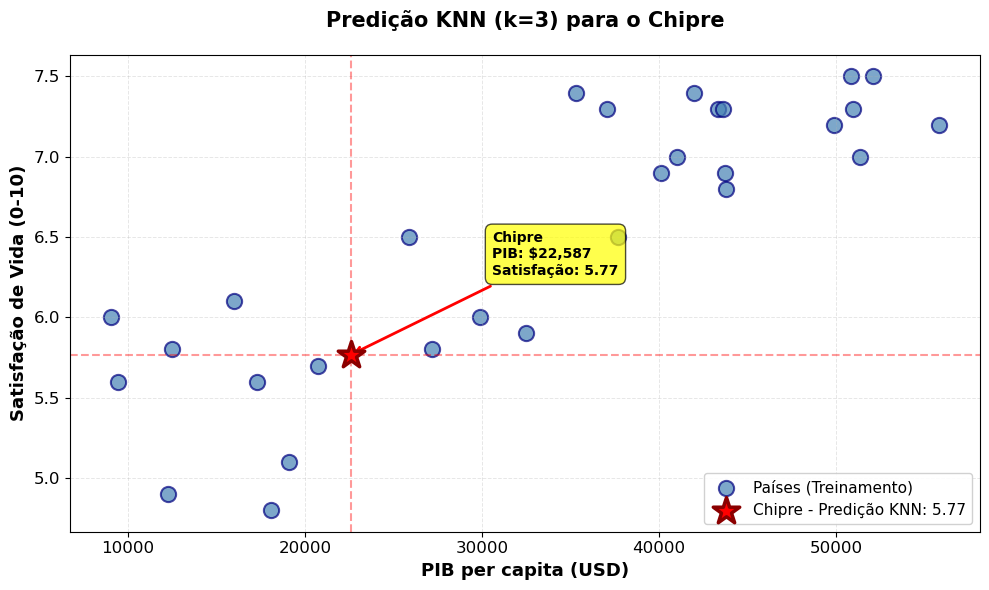


🎯 RESULTADO DA PREDIÇÃO:
   País: Chipre
   PIB per capita: $22,587
   Satisfação prevista (KNN): 5.7667


In [27]:
# Célula 2: Predição do KNN para o Chipre
import matplotlib.pyplot as plt

# Criar figura
plt.figure(figsize=(10, 6))

# Dados de treinamento
plt.scatter(X, y, color='steelblue', s=120, alpha=0.7, 
            edgecolors='navy', linewidths=1.5, label='Países (Treinamento)')

# Predição para o Chipre usando KNN
X_new = [[22587]]  # PIB do Chipre
y_pred_knn = model1.predict(X_new)

# Destacar a predição do Chipre com estrela vermelha
plt.scatter(X_new, y_pred_knn, color='red', s=400, marker='*', 
            edgecolors='darkred', linewidths=2.5, 
            label=f'Chipre - Predição KNN: {y_pred_knn[0][0]:.2f}', zorder=5)

# Linhas de referência pontilhadas
plt.axvline(x=22587, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axhline(y=y_pred_knn[0][0], color='red', linestyle='--', alpha=0.4, linewidth=1.5)

# Anotação com seta apontando para o Chipre
plt.annotate(f'Chipre\nPIB: ${X_new[0][0]:,}\nSatisfação: {y_pred_knn[0][0]:.2f}',
             xy=(X_new[0][0], y_pred_knn[0][0]), 
             xytext=(X_new[0][0] + 8000, y_pred_knn[0][0] + 0.5),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Configurações dos eixos
plt.xlabel('PIB per capita (USD)', fontsize=13, fontweight='bold')
plt.ylabel('Satisfação de Vida (0-10)', fontsize=13, fontweight='bold')

# Título
plt.title('Predição KNN (k=3) para o Chipre', 
          fontsize=15, fontweight='bold', pad=20)

# Grid
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Legenda
plt.legend(fontsize=11, loc='lower right', framealpha=0.9)

# Ajustar layout
plt.tight_layout()

# Exibir
plt.show()

# Resultado
print(f"\n🎯 RESULTADO DA PREDIÇÃO:")
print(f"   País: Chipre")
print(f"   PIB per capita: ${X_new[0][0]:,}")
print(f"   Satisfação prevista (KNN): {y_pred_knn[0][0]:.4f}")

c:\Users\cloud\miniconda3\envs\tf2\lib\site-packages\numpy\core\_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)


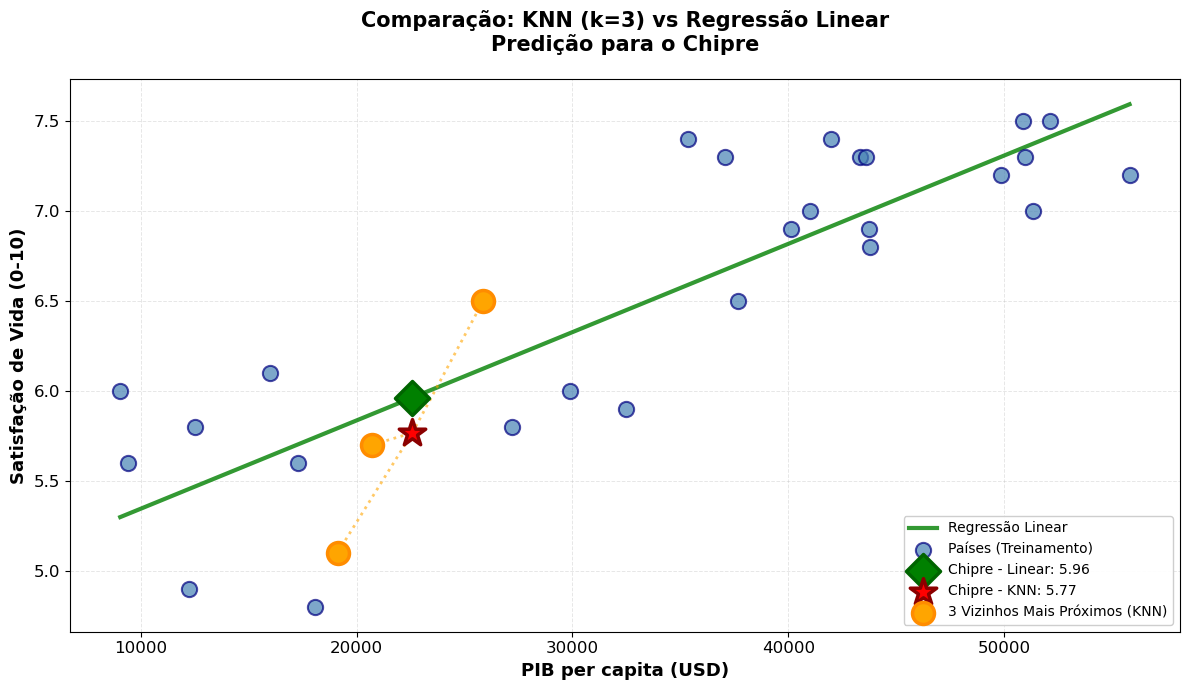


📊 COMPARAÇÃO DE MODELOS - PREDIÇÃO PARA O CHIPRE (PIB = $22,587)
🟢 Regressão Linear:     5.9624
🔴 KNN (k=3):            5.7667
📏 Diferença Absoluta:   0.1958
📐 Diferença Percentual: 3.28%

💡 Interpretação:
   • Regressão Linear usa tendência GLOBAL (linha reta)
   • KNN usa informação LOCAL (média dos 3 vizinhos laranja)
   • Ambos os modelos preveem satisfação moderada para o Chipre


In [28]:
# Célula 3: Comparação KNN vs Regressão Linear
import matplotlib.pyplot as plt
import numpy as np

# Criar figura maior
plt.figure(figsize=(12, 7))

# 1. Dados de treinamento
plt.scatter(X, y, color='steelblue', s=120, alpha=0.7, 
            edgecolors='navy', linewidths=1.5, label='Países (Treinamento)', zorder=3)

# 2. Linha de Regressão Linear
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred_linear_line = model.predict(X_range)
plt.plot(X_range, y_pred_linear_line, color='green', linewidth=3, 
         label='Regressão Linear', linestyle='-', alpha=0.8, zorder=2)

# 3. Predições para o Chipre
X_new = [[22587]]

# Predição Regressão Linear
y_pred_reg = model.predict(X_new)
plt.scatter(X_new, y_pred_reg, color='green', s=300, marker='D', 
            edgecolors='darkgreen', linewidths=2.5, 
            label=f'Chipre - Linear: {y_pred_reg[0][0]:.2f}', zorder=4)

# Predição KNN
y_pred_knn = model1.predict(X_new)
plt.scatter(X_new, y_pred_knn, color='red', s=400, marker='*', 
            edgecolors='darkred', linewidths=2.5, 
            label=f'Chipre - KNN: {y_pred_knn[0][0]:.2f}', zorder=5)

# 4. Identificar e destacar os 3 vizinhos mais próximos
distances = np.abs(X - X_new[0][0])
nearest_indices = distances.flatten().argsort()[:3]

# Destacar vizinhos em laranja
for idx in nearest_indices:
    plt.scatter(X[idx], y[idx], color='orange', s=250, marker='o', 
                edgecolors='darkorange', linewidths=2.5, zorder=4)
    # Linha conectando vizinho ao Chipre
    plt.plot([X[idx], X_new[0][0]], [y[idx], y_pred_knn[0][0]], 
             color='orange', linestyle=':', alpha=0.6, linewidth=2)

# Legenda para vizinhos
plt.scatter([], [], color='orange', s=250, marker='o', 
            edgecolors='darkorange', linewidths=2.5, 
            label='3 Vizinhos Mais Próximos (KNN)')

# Configurações
plt.xlabel('PIB per capita (USD)', fontsize=13, fontweight='bold')
plt.ylabel('Satisfação de Vida (0-10)', fontsize=13, fontweight='bold')
plt.title('Comparação: KNN (k=3) vs Regressão Linear\nPredição para o Chipre', 
          fontsize=15, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.legend(fontsize=10, loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.show()

# Resumo comparativo
print("\n" + "="*70)
print("📊 COMPARAÇÃO DE MODELOS - PREDIÇÃO PARA O CHIPRE (PIB = $22,587)")
print("="*70)
print(f"🟢 Regressão Linear:     {y_pred_reg[0][0]:.4f}")
print(f"🔴 KNN (k=3):            {y_pred_knn[0][0]:.4f}")
print(f"📏 Diferença Absoluta:   {abs(y_pred_reg[0][0] - y_pred_knn[0][0]):.4f}")
print(f"📐 Diferença Percentual: {abs(y_pred_reg[0][0] - y_pred_knn[0][0])/y_pred_reg[0][0]*100:.2f}%")
print("="*70)
print("\n💡 Interpretação:")
print("   • Regressão Linear usa tendência GLOBAL (linha reta)")
print("   • KNN usa informação LOCAL (média dos 3 vizinhos laranja)")
print("   • Ambos os modelos preveem satisfação moderada para o Chipre")

# Observação: você pode ignorar o restante deste notebook, ele apenas gera muitas das figuras do capítulo 1.

Create a function to save the figures.

In [32]:
# ========== CONFIGURAÇÃO PARA SALVAR FIGURAS ==========

# Onde salvar as figuras

# Define o diretório raiz do projeto (pasta atual)
PROJECT_ROOT_DIR = "."

# Define o ID do capítulo (usado para organizar as imagens por seção)
CHAPTER_ID = "fundamentals"

# Constrói o caminho completo para a pasta de imagens
# Exemplo: "./images/fundamentals"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)

# Cria a estrutura de pastas se ela não existir
# exist_ok=True evita erro se a pasta já existir
os.makedirs(IMAGES_PATH, exist_ok=True)


# ========== FUNÇÃO PARA SALVAR FIGURAS ==========

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """
    Salva a figura atual do matplotlib em um arquivo.
    
    Parâmetros:
    -----------
    fig_id : str
        Nome do arquivo (sem extensão)
        Exemplo: "grafico_dispersao"
    
    tight_layout : bool, opcional (default=True)
        Se True, ajusta automaticamente o layout da figura
        para evitar sobreposição de elementos
    
    fig_extension : str, opcional (default="png")
        Formato do arquivo de imagem
        Opções: "png", "jpg", "pdf", "svg"
    
    resolution : int, opcional (default=300)
        Resolução da imagem em DPI (dots per inch)
        300 DPI = qualidade profissional para impressão
        72-96 DPI = qualidade para tela
    """
    
    # Constrói o caminho completo do arquivo
    # Exemplo: "./images/fundamentals/grafico_dispersao.png"
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    
    # Mensagem informativa
    print("Salvando figura", fig_id)
    
    # Aplica tight_layout se solicitado
    if tight_layout:
        plt.tight_layout()
    
    # Salva a figura com as configurações especificadas
    plt.savefig(path, format=fig_extension, dpi=resolution)

Make this notebook's output stable across runs:

In [31]:
np.random.seed(42)

# Carregar e preparar os dados de Satisfação com a Vida


# Se quiser, você pode obter dados atualizados no site da OCDE.
# Baixe o arquivo CSV de http://stats.oecd.org/index.aspx?DataSetCode=BLI
# e salve-o em `datasets/lifesat/`.


# 📊 Carregamento e Processamento dos Dados OECD

Este código carrega e transforma os dados do **OECD Better Life Index** (Índice de Vida Melhor da OCDE) de 2015, preparando-os para análise.

---

## 📋 Código Comentado:
```python

In [34]:
# ============ CARREGAMENTO E PROCESSAMENTO DOS DADOS OECD ============

# Carrega o arquivo CSV com dados de qualidade de vida da OECD (2015)
# thousands=',' reconhece separador de milhares (ex: 1,000 ou 10,000)
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')

# Filtra apenas os dados TOTAIS (remove segmentações por gênero, idade, etc.)
# INEQUALITY="TOT" = dados agregados de toda a população
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]

# Reorganiza de formato LONGO para formato LARGO usando pivot:
# - index="Country" → Países viram linhas (índice)
# - columns="Indicator" → Indicadores viram colunas (Life satisfaction, Housing, etc.)
# - values="Value" → Valores preenchem as células da tabela
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")

# Exibe as 2 primeiras linhas para verificar a transformação
# Resultado: Cada país em uma linha, cada indicador em uma coluna
oecd_bli.head(2)

Indicator,Air pollution,Assault rate,Consultation on rule-making,Dwellings without basic facilities,Educational attainment,Employees working very long hours,Employment rate,Homicide rate,Household net adjusted disposable income,Household net financial wealth,...,Long-term unemployment rate,Personal earnings,Quality of support network,Rooms per person,Self-reported health,Student skills,Time devoted to leisure and personal care,Voter turnout,Water quality,Years in education
Country,,,,,,,,,,,,,,,,,,,,,
Australia,13.0,2.1,10.5,1.1,76.0,14.02,72.0,0.8,31588.0,47657.0,...,1.08,50449.0,92.0,2.3,85.0,512.0,14.41,93.0,91.0,19.4
Austria,27.0,3.4,7.1,1.0,83.0,7.61,72.0,0.4,31173.0,49887.0,...,1.19,45199.0,89.0,1.6,69.0,500.0,14.46,75.0,94.0,17.0


In [35]:
# Acessa a coluna "Life satisfaction" (Satisfação de Vida) do DataFrame
# e exibe os primeiros 5 países (comportamento padrão do .head())
oecd_bli["Life satisfaction"].head()

Country
Australia    7.3
Austria      6.9
Belgium      6.9
Brazil       7.0
Canada       7.3
Name: Life satisfaction, dtype: float64

# Carregar e preparar os dados de PIB per capita


# Assim como acima, você pode atualizar os dados de PIB per capita se quiser.
# Basta baixar os dados de http://goo.gl/j1MSKe (=> imf.org)
# e salvá-los em `datasets/lifesat/`.


In [36]:
# ============ CARREGAMENTO E PROCESSAMENTO DOS DADOS DE PIB ============

# Carrega o arquivo CSV com dados de PIB per capita
gdp_per_capita = pd.read_csv(datapath+"gdp_per_capita.csv", 
                             thousands=',',        # Reconhece separador de milhares (ex: 50,000)
                             delimiter='\t',       # Arquivo separado por TAB (não vírgula)
                             encoding='latin1',    # Codificação para caracteres especiais (ç, é, á, etc.)
                             na_values="n/a")      # Trata "n/a" como valor ausente (NaN)

# Renomeia a coluna "2015" para "GDP per capita" (nome mais descritivo)
# inplace=True modifica o DataFrame original (sem criar cópia)
gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)

# Define a coluna "Country" como índice do DataFrame
# Facilita o merge com outros datasets que também usam países como índice
# inplace=True modifica o DataFrame original
gdp_per_capita.set_index("Country", inplace=True)

# Exibe as 2 primeiras linhas para verificar a transformação
gdp_per_capita.head(2)

,Subject Descriptor,Units,Scale,Country/Series-specific Notes,GDP per capita,Estimates Start After
Country,,,,,,
Afghanistan,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",599.994,2013.0
Albania,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",3995.383,2010.0


In [37]:
# ============ JUNÇÃO E ORDENAÇÃO DOS DADOS ============

# Combina os dois DataFrames (OECD e PIB) em um único DataFrame
# usando os ÍNDICES (países) como chave de junção
full_country_stats = pd.merge(left=oecd_bli,              # DataFrame da esquerda (indicadores OECD)
                               right=gdp_per_capita,       # DataFrame da direita (PIB per capita)
                               left_index=True,            # Usa o índice do DataFrame esquerdo (Country)
                               right_index=True)           # Usa o índice do DataFrame direito (Country)
# Tipo de merge: INNER JOIN (padrão) - mantém apenas países presentes em AMBOS os datasets

# Ordena os países por PIB per capita em ordem CRESCENTE (do mais pobre ao mais rico)
# inplace=True modifica o DataFrame original (sem criar cópia)
full_country_stats.sort_values(by="GDP per capita", inplace=True)

# Exibe o DataFrame completo com todos os países e indicadores combinados
full_country_stats

,Air pollution,Assault rate,Consultation on rule-making,Dwellings without basic facilities,Educational attainment,Employees working very long hours,Employment rate,Homicide rate,Household net adjusted disposable income,Household net financial wealth,...,Time devoted to leisure and personal care,Voter turnout,Water quality,Years in education,Subject Descriptor,Units,Scale,Country/Series-specific Notes,GDP per capita,Estimates Start After
Country,,,,,,,,,,,,,,,,,,,,,
Brazil,18.0,7.9,4.0,6.7,45.0,10.41,67.0,25.5,11664.0,6844.0,...,14.97,79.0,72.0,16.3,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",8669.998,2014.0
Mexico,30.0,12.8,9.0,4.2,37.0,28.83,61.0,23.4,13085.0,9056.0,...,13.89,63.0,67.0,14.4,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",9009.280,2015.0
Russia,15.0,3.8,2.5,15.1,94.0,0.16,69.0,12.8,19292.0,3412.0,...,14.97,65.0,56.0,16.0,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",9054.914,2015.0
Turkey,35.0,5.0,5.5,12.7,34.0,40.86,50.0,1.2,14095.0,3251.0,...,13.42,88.0,62.0,16.4,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",9437.372,2013.0
Hungary,15.0,3.6,7.9,4.8,82.0,3.19,58.0,1.3,15442.0,13277.0,...,15.04,62.0,77.0,17.6,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",12239.894,2015.0
Poland,33.0,1.4,10.8,3.2,90.0,7.41,60.0,0.9,17852.0,10919.0,...,14.20,55.0,79.0,18.4,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",12495.334,2014.0
Chile,46.0,6.9,2.0,9.4,57.0,15.42,62.0,4.4,14533.0,17733.0,...,14.41,49.0,73.0,16.5,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",13340.905,2014.0
Slovak Republic,13.0,3.0,6.6,0.6,92.0,7.02,60.0,1.2,17503.0,8663.0,...,14.99,59.0,81.0,16.3,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",15991.736,2015.0
Czech Republic,16.0,2.8,6.8,0.9,92.0,6.98,68.0,0.8,18404.0,17299.0,...,14.98,59.0,85.0,18.1,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",17256.918,2015.0


In [38]:
# ============ ACESSO A DADOS ESPECÍFICOS DE UM PAÍS ============

# Seleciona apenas 2 colunas e depois acessa a linha dos Estados Unidos
full_country_stats[["GDP per capita", 'Life satisfaction']].loc["United States"]

# Quebra do código:
# 1. full_country_stats[["GDP per capita", 'Life satisfaction']]
#    ↑ Seleciona APENAS as colunas de PIB e Satisfação de Vida
# 2. .loc["United States"]
#    ↑ Acessa a LINHA correspondente ao país "United States"

GDP per capita       55805.204
Life satisfaction        7.200
Name: United States, dtype: float64

In [39]:
# ============ REMOÇÃO DE OUTLIERS E SEPARAÇÃO DOS DADOS ============

# Define os ÍNDICES (posições) dos países que serão REMOVIDOS
# Estes são outliers ou países com dados problemáticos
remove_indices = [0, 1, 6, 8, 33, 34, 35]
# São 7 países que serão excluídos da análise

# Cria uma lista com os índices que serão MANTIDOS
# Operação de conjuntos: todos os índices (0 a 35) MENOS os removidos
keep_indices = list(set(range(36)) - set(remove_indices))
# range(36) = {0, 1, 2, 3, ..., 35} (36 países no total)
# set(remove_indices) = {0, 1, 6, 8, 33, 34, 35}
# Diferença = {2, 3, 4, 5, 7, 9, 10, ..., 32} (29 países mantidos)

# Cria o dataset PRINCIPAL com apenas PIB e Satisfação dos países MANTIDOS
# iloc[] acessa por POSIÇÃO numérica (não por nome do país)
sample_data = full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]
# Resultado: 29 países que serão usados no treinamento

# Cria um dataset SEPARADO com os países REMOVIDOS (para análise posterior)
missing_data = full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[remove_indices]
# Resultado: 7 países excluídos (outliers ou dados problemáticos)

Salvando figura money_happy_scatterplot


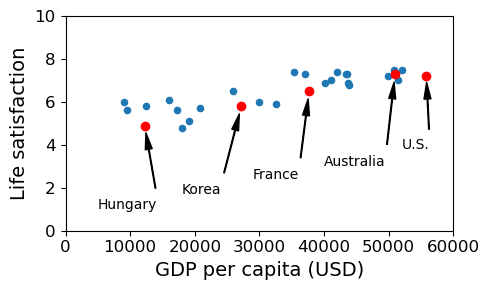

In [40]:
# ============ GRÁFICO DE DISPERSÃO COM ANOTAÇÕES PERSONALIZADAS ============

# Cria um gráfico de dispersão (scatter plot) com os dados filtrados
sample_data.plot(kind='scatter',                  # Tipo: gráfico de dispersão
                 x="GDP per capita",              # Eixo X: PIB per capita
                 y='Life satisfaction',           # Eixo Y: Satisfação de vida
                 figsize=(5,3))                   # Tamanho: 5 polegadas (largura) x 3 (altura)

# Define os limites dos eixos do gráfico
plt.axis([0, 60000, 0, 10])
# [x_min, x_max, y_min, y_max]
# X: de 0 a 60,000 USD (PIB per capita)
# Y: de 0 a 10 (Satisfação de vida - escala 0 a 10)

# Dicionário com POSIÇÕES PERSONALIZADAS para os TEXTOS das anotações
# Chave: Nome do país
# Valor: Tupla (x, y) onde o TEXTO da anotação será posicionado
position_text = {
    "Hungary": (5000, 1),              # Hungria: texto em x=5000, y=1
    "Korea": (18000, 1.7),             # Coreia: texto em x=18000, y=1.7
    "France": (29000, 2.4),            # França: texto em x=29000, y=2.4
    "Australia": (40000, 3.0),         # Austrália: texto em x=40000, y=3.0
    "United States": (52000, 3.8),     # EUA: texto em x=52000, y=3.8
}
# Nota: Estes NÃO são os valores reais dos países, são POSIÇÕES do TEXTO no gráfico

# Loop que adiciona anotações (labels) para cada país especificado
for country, pos_text in position_text.items():
    # country = nome do país (ex: "Hungary")
    # pos_text = tupla com posição do texto (ex: (5000, 1))
    
    # Obtém os valores REAIS de PIB e Satisfação do país no dataset
    pos_data_x, pos_data_y = sample_data.loc[country]
    # pos_data_x = PIB real do país
    # pos_data_y = Satisfação real do país
    
    # Abrevia "United States" para "U.S." (mais compacto no gráfico)
    country = "U.S." if country == "United States" else country
    
    # Cria a anotação (texto + seta apontando para o ponto)
    plt.annotate(country,                           # Texto a exibir
                 xy=(pos_data_x, pos_data_y),       # PONTO DE DADOS (onde a seta aponta)
                 xytext=pos_text,                   # POSIÇÃO DO TEXTO (onde o label aparece)
                 arrowprops=dict(                   # Propriedades da seta
                     facecolor='black',             # Cor da seta: preta
                     width=0.5,                     # Largura da linha da seta
                     shrink=0.1,                    # Encolhe a seta 10% (evita sobrepor o ponto)
                     headwidth=5))                  # Largura da ponta da seta
    
    # Marca o ponto de dados com um círculo VERMELHO
    plt.plot(pos_data_x, pos_data_y, "ro")
    # "ro" = red (vermelho) + o (círculo)

# Adiciona rótulo ao eixo X
plt.xlabel("GDP per capita (USD)")

# Salva o gráfico como arquivo de imagem (usando a função definida anteriormente)
save_fig('money_happy_scatterplot')
# Será salvo em: ./images/fundamentals/money_happy_scatterplot.png

# Exibe o gráfico no notebook
plt.show()

In [41]:
# ============ SALVAMENTO DOS DADOS PROCESSADOS EM CSV ============

# Salva o DataFrame sample_data (dados filtrados) em um arquivo CSV
sample_data.to_csv(os.path.join("datasets", "lifesat", "lifesat.csv"))

# Quebra do código:
# 1. os.path.join("datasets", "lifesat", "lifesat.csv")
#    ↑ Constrói o caminho completo do arquivo de forma multiplataforma
#    Resultado: "datasets/lifesat/lifesat.csv" (Linux/Mac)
#            ou "datasets\lifesat\lifesat.csv" (Windows)
#
# 2. sample_data.to_csv(...)
#    ↑ Exporta o DataFrame para um arquivo CSV
#    Inclui: índice (países) + colunas (GDP per capita, Life satisfaction)

In [42]:
# ============ ACESSO AOS DADOS DOS PAÍSES ANOTADOS NO GRÁFICO ============

# Seleciona apenas as linhas dos países que foram destacados no gráfico anterior
sample_data.loc[list(position_text.keys())]

# Quebra do código:
# 1. position_text.keys()
#    ↑ Retorna as CHAVES do dicionário (nomes dos países anotados)
#    Resultado: dict_keys(['Hungary', 'Korea', 'France', 'Australia', 'United States'])
#
# 2. list(position_text.keys())
#    ↑ Converte para lista
#    Resultado: ['Hungary', 'Korea', 'France', 'Australia', 'United States']
#
# 3. sample_data.loc[lista_de_países]
#    ↑ Seleciona apenas as LINHAS desses 5 países específicos
#    Retorna um DataFrame com os dados reais de PIB e Satisfação

,GDP per capita,Life satisfaction
Country,,
Hungary,12239.894,4.9
Korea,27195.197,5.8
France,37675.006,6.5
Australia,50961.865,7.3
United States,55805.204,7.2


Salvando figura tweaking_model_params_plot


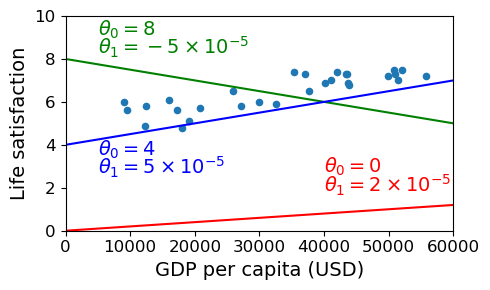

In [43]:
# ============ VISUALIZAÇÃO DE DIFERENTES MODELOS LINEARES ============

import numpy as np

# Cria o gráfico de dispersão base com os dados
sample_data.plot(kind='scatter',              # Tipo: scatter plot
                 x="GDP per capita",          # Eixo X: PIB per capita
                 y='Life satisfaction',       # Eixo Y: Satisfação de vida
                 figsize=(5,3))               # Tamanho: 5x3 polegadas

# Adiciona rótulo ao eixo X
plt.xlabel("GDP per capita (USD)")

# Define os limites dos eixos [x_min, x_max, y_min, y_max]
plt.axis([0, 60000, 0, 10])

# Cria 1000 pontos igualmente espaçados entre 0 e 60000 (para linhas suaves)
X = np.linspace(0, 60000, 1000)
# X será usado como valores de PIB para desenhar as linhas dos modelos


# ========== MODELO 1: LINHA VERMELHA (Inclinação positiva pequena) ==========
plt.plot(X, 2*X/100000, "r")
# Equação: y = 2X/100000 = 0.00002X
# Forma: y = θ₀ + θ₁X onde θ₀=0, θ₁=0.00002
# "r" = red (vermelho)
# Esta linha passa pela origem e tem inclinação muito pequena

# Anotação dos parâmetros do modelo vermelho
plt.text(40000, 2.7, r"$\theta_0 = 0$", fontsize=14, color="r")
# r"$...$" = formato LaTeX para notação matemática
# Posição: x=40000, y=2.7
plt.text(40000, 1.8, r"$\theta_1 = 2 \times 10^{-5}$", fontsize=14, color="r")
# θ₁ = 2×10⁻⁵ = 0.00002 (inclinação muito pequena)


# ========== MODELO 2: LINHA VERDE (Inclinação negativa) ==========
plt.plot(X, 8 - 5*X/100000, "g")
# Equação: y = 8 - 5X/100000 = 8 - 0.00005X
# Forma: y = θ₀ + θ₁X onde θ₀=8, θ₁=-0.00005
# "g" = green (verde)
# Linha começa em y=8 e DESCE (inclinação negativa)

# Anotação dos parâmetros do modelo verde
plt.text(5000, 9.1, r"$\theta_0 = 8$", fontsize=14, color="g")
# θ₀ = 8 (intercepto no eixo Y)
plt.text(5000, 8.2, r"$\theta_1 = -5 \times 10^{-5}$", fontsize=14, color="g")
# θ₁ = -5×10⁻⁵ = -0.00005 (inclinação NEGATIVA)


# ========== MODELO 3: LINHA AZUL (Inclinação positiva moderada) ==========
plt.plot(X, 4 + 5*X/100000, "b")
# Equação: y = 4 + 5X/100000 = 4 + 0.00005X
# Forma: y = θ₀ + θ₁X onde θ₀=4, θ₁=0.00005
# "b" = blue (azul)
# Linha começa em y=4 e SOBE com inclinação moderada

# Anotação dos parâmetros do modelo azul
plt.text(5000, 3.5, r"$\theta_0 = 4$", fontsize=14, color="b")
# θ₀ = 4 (intercepto no eixo Y)
plt.text(5000, 2.6, r"$\theta_1 = 5 \times 10^{-5}$", fontsize=14, color="b")
# θ₁ = 5×10⁻⁵ = 0.00005 (inclinação positiva moderada)


# Salva o gráfico
save_fig('tweaking_model_params_plot')
# Nome: "ajustando_parametros_do_modelo"

# Exibe o gráfico
plt.show()

In [44]:
# ============ TREINAMENTO DE REGRESSÃO LINEAR E EXTRAÇÃO DOS PARÂMETROS ============

# Importa o módulo de modelos lineares do scikit-learn
from sklearn import linear_model

# Cria uma instância do modelo de Regressão Linear
lin1 = linear_model.LinearRegression()
# Modelo vazio, ainda não treinado

# Prepara os dados de ENTRADA (features/variáveis independentes)
Xsample = np.c_[sample_data["GDP per capita"]]
# np.c_[] converte para array 2D (formato exigido pelo scikit-learn)
# Resultado: array com shape (29, 1) - 29 países, 1 feature

# Prepara os dados de SAÍDA (target/variável dependente)
ysample = np.c_[sample_data["Life satisfaction"]]
# np.c_[] converte para array 2D
# Resultado: array com shape (29, 1) - 29 países, 1 valor target

# TREINA o modelo com os dados
lin1.fit(Xsample, ysample)
# O modelo APRENDE a relação entre PIB (X) e Satisfação (y)
# Calcula os melhores valores de θ₀ (intercepto) e θ₁ (inclinação)
# Minimiza o erro quadrático médio (MSE)

# Extrai os PARÂMETROS aprendidos pelo modelo
t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]
# t0 = θ₀ = intercepto (onde a linha cruza o eixo Y quando X=0)
# t1 = θ₁ = inclinação (coeficiente angular da reta)
# lin1.intercept_[0] → primeiro elemento do array de interceptos
# lin1.coef_[0][0] → primeiro coeficiente da primeira feature

# Retorna os parâmetros aprendidos
t0, t1
# Saída esperada: (valor_de_θ₀, valor_de_θ₁)
# Exemplo: (4.853, 0.0000467) ou similar

(4.853052800266436, 4.911544589158484e-05)

Salvando figura best_fit_model_plot


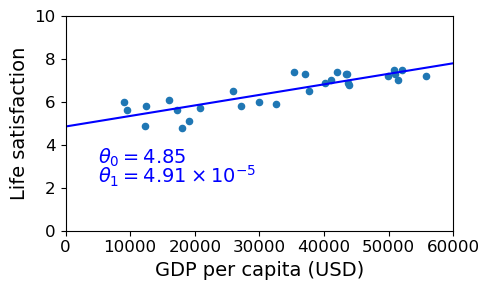

In [45]:
# ============ VISUALIZAÇÃO DA LINHA DE MELHOR AJUSTE (BEST FIT) ============

# Cria o gráfico de dispersão com os dados reais dos países
sample_data.plot(kind='scatter',              # Tipo: scatter plot
                 x="GDP per capita",          # Eixo X: PIB per capita
                 y='Life satisfaction',       # Eixo Y: Satisfação de vida
                 figsize=(5,3))               # Tamanho: 5x3 polegadas

# Adiciona rótulo ao eixo X
plt.xlabel("GDP per capita (USD)")

# Define os limites dos eixos [x_min, x_max, y_min, y_max]
plt.axis([0, 60000, 0, 10])

# Cria 1000 pontos igualmente espaçados entre 0 e 60000 (para linha suave)
X = np.linspace(0, 60000, 1000)

# Desenha a LINHA DE REGRESSÃO usando os parâmetros APRENDIDOS pelo modelo
plt.plot(X, t0 + t1*X, "b")
# Equação: y = t0 + t1*X
# t0 = θ₀ = intercepto (aprendido: ~4.85)
# t1 = θ₁ = inclinação (aprendido: ~0.0000491)
# "b" = blue (azul)
# Esta é a LINHA DE MELHOR AJUSTE que minimiza o erro quadrático

# Anotação do parâmetro θ₀ (intercepto)
plt.text(5000, 3.1, r"$\theta_0 = 4.85$", fontsize=14, color="b")
# θ₀ = 4.85 → satisfação base (quando PIB = 0)
# r"$...$" = formato LaTeX para notação matemática
# Posição do texto: x=5000, y=3.1

# Anotação do parâmetro θ₁ (inclinação)
plt.text(5000, 2.2, r"$\theta_1 = 4.91 \times 10^{-5}$", fontsize=14, color="b")
# θ₁ = 4.91×10⁻⁵ = 0.0000491 → aumento na satisfação por cada $1 de PIB
# Posição do texto: x=5000, y=2.2

# Salva o gráfico como imagem
save_fig('best_fit_model_plot')
# Nome: "gráfico_do_modelo_de_melhor_ajuste"
# Será salvo em: ./images/fundamentals/best_fit_model_plot.png

# Exibe o gráfico
plt.show()

In [46]:
# ============ PREDIÇÃO DA SATISFAÇÃO DE VIDA DO CHIPRE ============

# Obtém o PIB per capita do Chipre do dataset gdp_per_capita
cyprus_gdp_per_capita = gdp_per_capita.loc["Cyprus"]["GDP per capita"]
# .loc["Cyprus"] → acessa a linha do Chipre (usando o índice)
# ["GDP per capita"] → seleciona a coluna específica de PIB
# Resultado: valor escalar (ex: 22587.0)

# Exibe o valor do PIB do Chipre
print(cyprus_gdp_per_capita)
# Output esperado: 22587.0 (ou valor similar)

# Usa o modelo treinado (lin1) para PREVER a satisfação de vida do Chipre
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0][0]
# Quebra do código:
# 1. [[cyprus_gdp_per_capita]] → converte para array 2D (formato exigido)
#    Exemplo: [[22587]] → shape (1, 1)
# 2. lin1.predict(...) → aplica a equação y = θ₀ + θ₁ × PIB
#    Retorna array 2D: [[5.96]]
# 3. [0] → pega a primeira linha: [5.96]
# 4. [0] → pega o primeiro elemento: 5.96 (valor escalar)

# Retorna o valor previsto
cyprus_predicted_life_satisfaction
# Output: 5.96 (aproximadamente)
# Interpretação: O modelo prevê que o Chipre terá satisfação de vida de ~5.96

22587.49


5.96244744318815

Salvando figura cyprus_prediction_plot


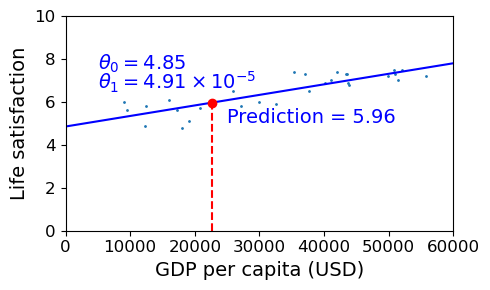

In [47]:
# ============ VISUALIZAÇÃO DA PREDIÇÃO PARA O CHIPRE ============

# Cria o gráfico de dispersão com pontos MUITO PEQUENOS (para destacar a predição)
sample_data.plot(kind='scatter',              # Tipo: scatter plot
                 x="GDP per capita",          # Eixo X: PIB per capita
                 y='Life satisfaction',       # Eixo Y: Satisfação de vida
                 figsize=(5,3),               # Tamanho: 5x3 polegadas
                 s=1)                         # s=1 → pontos minúsculos (quase invisíveis)
# Pontos menores deixam o foco na predição do Chipre

# Adiciona rótulo ao eixo X
plt.xlabel("GDP per capita (USD)")

# Cria 1000 pontos para desenhar a linha de regressão suavemente
X = np.linspace(0, 60000, 1000)

# Desenha a LINHA DE REGRESSÃO LINEAR aprendida
plt.plot(X, t0 + t1*X, "b")
# Equação: y = 4.85 + 0.0000491 × X
# "b" = blue (azul)

# Define os limites dos eixos
plt.axis([0, 60000, 0, 10])

# Anotação dos parâmetros do modelo (posicionados mais acima que antes)
plt.text(5000, 7.5, r"$\theta_0 = 4.85$", fontsize=14, color="b")
# θ₀ = intercepto

plt.text(5000, 6.6, r"$\theta_1 = 4.91 \times 10^{-5}$", fontsize=14, color="b")
# θ₁ = inclinação

# Desenha uma LINHA VERTICAL PONTILHADA VERMELHA do eixo X até a predição
plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita],     # X: mesmo valor (vertical)
         [0, cyprus_predicted_life_satisfaction],            # Y: de 0 até predição
         "r--")                                              # "r--" = red dashed (vermelho tracejado)
# Esta linha conecta visualmente o PIB do Chipre no eixo X até o ponto previsto

# Adiciona TEXTO mostrando o valor da predição
plt.text(25000, 5.0, r"Prediction = 5.96", fontsize=14, color="b")
# Mostra claramente o valor previsto para o Chipre

# Marca o PONTO DA PREDIÇÃO com um CÍRCULO VERMELHO GRANDE
plt.plot(cyprus_gdp_per_capita,                # X: PIB do Chipre (~22587)
         cyprus_predicted_life_satisfaction,   # Y: Satisfação prevista (~5.96)
         "ro")                                 # "ro" = red circle (círculo vermelho)
# Este ponto vermelho destaca a predição na linha azul

# Salva o gráfico
save_fig('cyprus_prediction_plot')
# Nome: "gráfico_de_predição_chipre"

# Exibe o gráfico
plt.show()

In [48]:
# ============ SELEÇÃO DE LINHAS POR POSIÇÃO (SLICING) ============

# Seleciona as linhas nas POSIÇÕES 7, 8 e 9 do DataFrame
sample_data[7:10]

# Slicing: [início:fim]
# início = 7 → começa na linha de índice 7 (INCLUÍDO)
# fim = 10 → termina ANTES da linha 10 (EXCLUÍDO)
# Resultado: linhas 7, 8, 9 (3 linhas no total)

# Nota: Isso usa POSIÇÃO numérica, não o nome do índice (país)

,GDP per capita,Life satisfaction
Country,,
Portugal,19121.592,5.1
Slovenia,20732.482,5.7
Spain,25864.721,6.5


In [49]:
# ============ CÁLCULO DA MÉDIA DE TRÊS VALORES ============

# Calcula a MÉDIA ARITMÉTICA de três valores de satisfação de vida
(5.1 + 5.7 + 6.5) / 3

# Passo a passo:
# 1. Soma: 5.1 + 5.7 + 6.5 = 17.3
# 2. Divide por 3: 17.3 / 3 = 5.766666...
# Resultado: 5.766666666666667 (ou 5.77 arredondado)

5.766666666666667

In [50]:
# ============ BACKUP E DEFINIÇÃO DA FUNÇÃO DE PREPARAÇÃO DE DADOS ============

# Cria um BACKUP (cópia) dos DataFrames originais antes de qualquer modificação
backup = oecd_bli, gdp_per_capita
# Armazena uma tupla com os dois DataFrames originais
# Útil para restaurar os dados caso sejam modificados acidentalmente
# Uso posterior: oecd_bli, gdp_per_capita = backup


# ============ FUNÇÃO COMPLETA DE PREPARAÇÃO DOS DADOS ============

def prepare_country_stats(oecd_bli, gdp_per_capita):
    """
    Processa e combina dados OECD e PIB per capita para Machine Learning.
    
    Parâmetros:
    -----------
    oecd_bli : DataFrame
        Dados brutos do OECD Better Life Index
    gdp_per_capita : DataFrame
        Dados brutos de PIB per capita
    
    Retorna:
    --------
    DataFrame
        Dataset limpo com 29 países e 2 colunas (GDP per capita, Life satisfaction)
    """
    
    # PASSO 1: Filtrar apenas dados totais (remove segmentações por desigualdade)
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    # Remove dados segmentados por gênero, idade, etc.
    # Mantém apenas valores agregados (INEQUALITY="TOT")
    
    # PASSO 2: Reorganizar dados OECD (formato longo → formato largo)
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    # index="Country" → países viram linhas
    # columns="Indicator" → indicadores viram colunas
    # values="Value" → valores preenchem as células
    # Resultado: uma linha por país, uma coluna por indicador
    
    # PASSO 3: Renomear coluna do PIB para nome mais descritivo
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    # Muda "2015" → "GDP per capita"
    # inplace=True modifica o DataFrame original
    
    # PASSO 4: Definir "Country" como índice do DataFrame de PIB
    gdp_per_capita.set_index("Country", inplace=True)
    # Facilita o merge posterior (ambos DataFrames usarão países como índice)
    
    # PASSO 5: Juntar os dois DataFrames usando países como chave
    full_country_stats = pd.merge(left=oecd_bli,           # DataFrame esquerdo
                                  right=gdp_per_capita,     # DataFrame direito
                                  left_index=True,          # Usa índice esquerdo
                                  right_index=True)         # Usa índice direito
    # Tipo de merge: INNER JOIN (mantém apenas países presentes em ambos)
    
    # PASSO 6: Ordenar países por PIB per capita (crescente: pobre → rico)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    # Facilita identificação de outliers e padrões
    
    # PASSO 7: Definir índices (posições) de países a serem REMOVIDOS
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    # 7 países outliers ou com dados problemáticos
    # Posições 0,1: países mais pobres
    # Posições 33,34,35: países mais ricos
    # Posições 6,8: dados inconsistentes
    
    # PASSO 8: Criar lista com índices a serem MANTIDOS
    keep_indices = list(set(range(36)) - set(remove_indices))
    # range(36) = {0,1,2,...,35} (36 países no total)
    # Subtrai os removidos: {2,3,4,5,7,9,...,32} (29 países mantidos)
    # Operação de conjuntos para calcular o complemento
    
    # PASSO 9: Retornar apenas as colunas relevantes e países filtrados
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]
    # [["GDP per capita", 'Life satisfaction']] → seleciona 2 colunas
    # .iloc[keep_indices] → seleciona apenas as 29 linhas mantidas
    # Resultado final: DataFrame com 29 linhas × 2 colunas

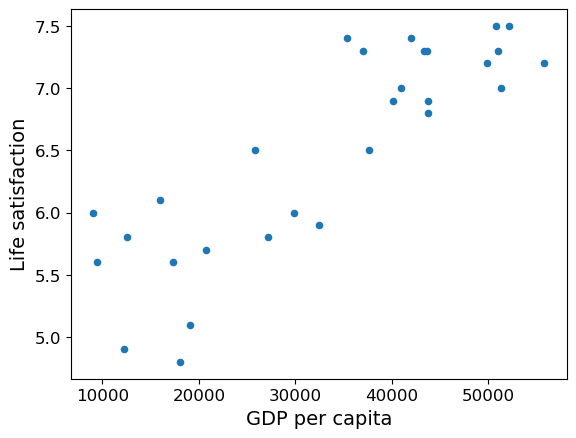

[[5.96242338]]


In [52]:
# ============ EXEMPLO COMPLETO DE MACHINE LEARNING ============
# Pipeline completo: Carregamento → Preparação → Visualização → Treinamento → Predição

# Importar bibliotecas necessárias
import matplotlib.pyplot as plt      # Visualização de gráficos
import numpy as np                  # Operações numéricas e arrays
import pandas as pd                 # Manipulação de dados tabulares
import sklearn.linear_model         # Algoritmos de Machine Learning (Regressão Linear)


# ========== 1️⃣ CARREGAR OS DADOS ==========

# Carrega dados de qualidade de vida (OECD Better Life Index 2015)
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')
# thousands=',' → reconhece separador de milhares em números

# Carrega dados de PIB per capita de diversos países
gdp_per_capita = pd.read_csv(datapath + "gdp_per_capita.csv",
                             thousands=',',        # Separador de milhares
                             delimiter='\t',       # Arquivo separado por TABs
                             encoding='latin1',    # Codificação para caracteres especiais (ç, é, ñ)
                             na_values="n/a")      # Trata "n/a" como valor ausente (NaN)


# ========== 2️⃣ PREPARAR OS DADOS ==========

# Limpa, filtra e combina os dois datasets
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
# Função retorna DataFrame com 29 países e 2 colunas:
# - GDP per capita (variável independente/feature)
# - Life satisfaction (variável dependente/target)

# Prepara a variável INDEPENDENTE (feature/entrada do modelo)
X = np.c_[country_stats["GDP per capita"]]
# np.c_[] converte para array 2D (formato exigido pelo scikit-learn)
# Shape: (29, 1) → 29 países, 1 feature
# X representa "o que usamos para PREVER"

# Prepara a variável DEPENDENTE (target/saída do modelo)
y = np.c_[country_stats["Life satisfaction"]]
# np.c_[] converte para array 2D
# Shape: (29, 1) → 29 países, 1 valor target
# y representa "o que queremos PREVER"


# ========== 3️⃣ VISUALIZAR OS DADOS ==========

# Cria gráfico de dispersão para entender a relação entre PIB e satisfação
country_stats.plot(kind='scatter',           # Tipo: scatter plot
                   x="GDP per capita",       # Eixo X: PIB
                   y='Life satisfaction')    # Eixo Y: Satisfação
plt.show()
# Mostra correlação positiva: países mais ricos tendem a ser mais felizes


# ========== 4️⃣ SELECIONAR UM MODELO ==========

# Escolhe o algoritmo de Regressão Linear
model = sklearn.linear_model.LinearRegression()
# Cria uma instância do modelo (ainda não treinado)
# Regressão Linear: y = θ₀ + θ₁ × X (equação de uma reta)


# ========== 5️⃣ TREINAR O MODELO ==========

# O modelo APRENDE a relação entre PIB (X) e satisfação (y)
model.fit(X, y)
# fit() calcula os melhores valores de θ₀ (intercepto) e θ₁ (inclinação)
# Minimiza o erro quadrático médio (MSE)
# Após fit(), o modelo está "treinado" e pronto para fazer predições


# ========== 6️⃣ FAZER PREDIÇÕES ==========

# Define o PIB per capita do Chipre
X_new = [[22587]]  # PIB per capita do Chipre em USD (formato 2D)
# [[valor]] → array 2D com shape (1, 1) = 1 amostra, 1 feature

# Usa o modelo treinado para PREVER a satisfação do Chipre
print(model.predict(X_new))  # saída: [[5.96242338]]
# Predição: O Chipre terá satisfação de vida de ~5.96 (em escala de 0 a 10)
# Cálculo: y = θ₀ + θ₁ × 22587 ≈ 4.85 + 0.0000491 × 22587 ≈ 5.96

In [54]:
# ============ RESTAURAÇÃO DOS DADOS ORIGINAIS A PARTIR DO BACKUP ============

# Restaura os DataFrames para seus estados ORIGINAIS (antes de qualquer modificação)
oecd_bli, gdp_per_capita = backup

# O que acontece:
# 1. backup é uma TUPLA com 2 elementos: (oecd_bli_original, gdp_per_capita_original)
# 2. Desempacotamento de tupla: atribui cada elemento a uma variável
# 3. oecd_bli recebe o primeiro elemento (DataFrame OECD original)
# 4. gdp_per_capita recebe o segundo elemento (DataFrame PIB original)
# 5. Qualquer modificação feita anteriormente é DESCARTADA

In [55]:
# ============ VISUALIZAÇÃO DOS DADOS REMOVIDOS (OUTLIERS) ============

# Exibe o DataFrame contendo os 7 países que foram REMOVIDOS da análise
missing_data

# O que contém:
# - Os 7 países nas posições [0, 1, 6, 8, 33, 34, 35] (após ordenação por PIB)
# - 2 colunas: GDP per capita, Life satisfaction
# - Estes são os OUTLIERS excluídos do treinamento do modelo

# missing_data foi criado anteriormente assim:
# missing_data = full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[remove_indices]

,GDP per capita,Life satisfaction
Country,,
Brazil,8669.998,7.0
Mexico,9009.280,6.7
Chile,13340.905,6.7
Czech Republic,17256.918,6.5
Norway,74822.106,7.4
Switzerland,80675.308,7.5
Luxembourg,101994.093,6.9


In [57]:
# ============ DICIONÁRIO DE POSIÇÕES PARA ANOTAÇÕES DE OUTLIERS ============

# Define as POSIÇÕES onde os TEXTOS (labels) dos países aparecerão no gráfico
# Este dicionário é para anotar os países REMOVIDOS (outliers)
position_text2 = {
    "Brazil": (1000, 9.0),              # Brasil: texto em x=1000, y=9.0
    "Mexico": (11000, 9.0),             # México: texto em x=11000, y=9.0
    "Chile": (25000, 9.0),              # Chile: texto em x=25000, y=9.0
    "Czech Republic": (35000, 9.0),     # República Tcheca: texto em x=35000, y=9.0
    "Norway": (60000, 3),               # Noruega: texto em x=60000, y=3
    "Switzerland": (72000, 3.0),        # Suíça: texto em x=72000, y=3.0
    "Luxembourg": (90000, 3.0),         # Luxemburgo: texto em x=90000, y=3.0
}

# Estrutura:
# Chave: Nome do país (string)
# Valor: Tupla (x, y) com coordenadas onde o TEXTO será posicionado
# 
# ⚠️ IMPORTANTE: Estes NÃO são os valores REAIS de PIB/Satisfação!
# São apenas as POSIÇÕES no gráfico onde os RÓTULOS aparecerão
#
# Divisão visual:
# - Países pobres (y=9.0): Brasil, México, Chile, Czech Rep. ← Topo do gráfico
# - Países ricos (y=3.0): Noruega, Suíça, Luxemburgo ← Parte inferior

Salvando figura representative_training_data_scatterplot


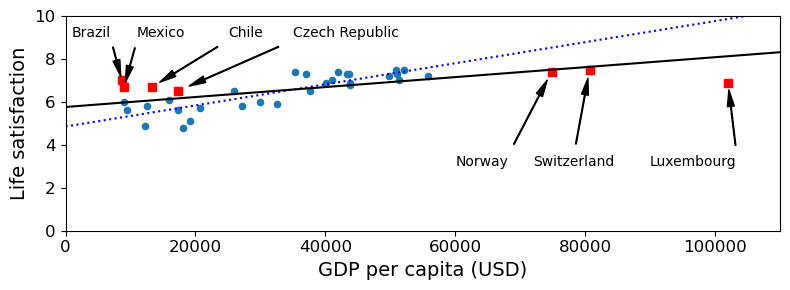

In [58]:
# ============ COMPARAÇÃO: MODELO COM vs SEM OUTLIERS ============
# Este gráfico mostra como outliers afetam a linha de regressão

# Cria gráfico de dispersão com os dados LIMPOS (sem outliers)
sample_data.plot(kind='scatter',              # Tipo: scatter plot
                 x="GDP per capita",          # Eixo X: PIB per capita
                 y='Life satisfaction',       # Eixo Y: Satisfação de vida
                 figsize=(8,3))               # Tamanho: 8x3 (mais largo para acomodar outliers ricos)

# Define limites dos eixos (expandido para incluir outliers extremos)
plt.axis([0, 110000, 0, 10])
# X: 0 a 110,000 USD (inclui Luxemburgo com ~$90-100k)
# Y: 0 a 10 (escala completa de satisfação)


# ========== ANOTAÇÃO DOS PAÍSES OUTLIERS (REMOVIDOS) ==========

# Loop para adicionar anotações dos 7 países outliers
for country, pos_text in position_text2.items():
    # country = nome do país (ex: "Brazil", "Norway")
    # pos_text = tupla com posição do texto (ex: (1000, 9.0))
    
    # Obtém os valores REAIS de PIB e Satisfação do país (dos dados removidos)
    pos_data_x, pos_data_y = missing_data.loc[country]
    # pos_data_x = PIB real do país
    # pos_data_y = Satisfação real do país
    
    # Cria anotação com seta apontando para o ponto de dados
    plt.annotate(country,                           # Texto a exibir
                 xy=(pos_data_x, pos_data_y),       # Posição do PONTO DE DADOS (onde seta aponta)
                 xytext=pos_text,                   # Posição do TEXTO (label)
                 arrowprops=dict(                   # Propriedades da seta
                     facecolor='black',             # Cor: preta
                     width=0.5,                     # Largura da linha
                     shrink=0.1,                    # Encolhe 10% (evita sobrepor ponto)
                     headwidth=5))                  # Largura da ponta
    
    # Marca o ponto do outlier com QUADRADO VERMELHO
    plt.plot(pos_data_x, pos_data_y, "rs")
    # "rs" = red square (quadrado vermelho)
    # Diferente dos pontos normais (círculos azuis)


# ========== LINHA DE REGRESSÃO SEM OUTLIERS (AZUL PONTILHADA) ==========

# Cria 1000 pontos para linha suave
X = np.linspace(0, 110000, 1000)

# Desenha a linha do modelo treinado SEM outliers (t0, t1 do modelo anterior)
plt.plot(X, t0 + t1*X, "b:")
# "b:" = blue dotted (azul pontilhado)
# t0 ≈ 4.85, t1 ≈ 0.0000491 (valores do modelo "sample_data")
# Esta linha foi treinada com apenas 29 países (sem os 7 outliers)


# ========== LINHA DE REGRESSÃO COM OUTLIERS (PRETA SÓLIDA) ==========

# Cria um NOVO modelo de regressão linear
lin_reg_full = linear_model.LinearRegression()

# Prepara dados COMPLETOS (todos os 36 países, incluindo outliers)
Xfull = np.c_[full_country_stats["GDP per capita"]]
# full_country_stats tem TODOS os países (antes da remoção)
# Shape: (36, 1)

yfull = np.c_[full_country_stats["Life satisfaction"]]
# Satisfação de todos os 36 países
# Shape: (36, 1)

# Treina o modelo com TODOS os dados (incluindo outliers)
lin_reg_full.fit(Xfull, yfull)
# Este modelo será "puxado" pelos outliers extremos

# Extrai os parâmetros aprendidos pelo modelo COMPLETO
t0full, t1full = lin_reg_full.intercept_[0], lin_reg_full.coef_[0][0]
# t0full = novo intercepto (com outliers)
# t1full = nova inclinação (com outliers)
# Valores serão DIFERENTES de t0 e t1 (modelo sem outliers)

# Cria pontos para desenhar a linha
X = np.linspace(0, 110000, 1000)

# Desenha a linha do modelo COM outliers
plt.plot(X, t0full + t1full * X, "k")
# "k" = black (preto sólido)
# Esta linha será mais "achatada" devido aos outliers ricos

# Adiciona rótulo ao eixo X
plt.xlabel("GDP per capita (USD)")

# Salva o gráfico
save_fig('representative_training_data_scatterplot')
# Nome: "gráfico_de_dispersão_dados_representativos_de_treinamento"

# Exibe o gráfico
plt.show()

Salvando figura overfitting_model_plot


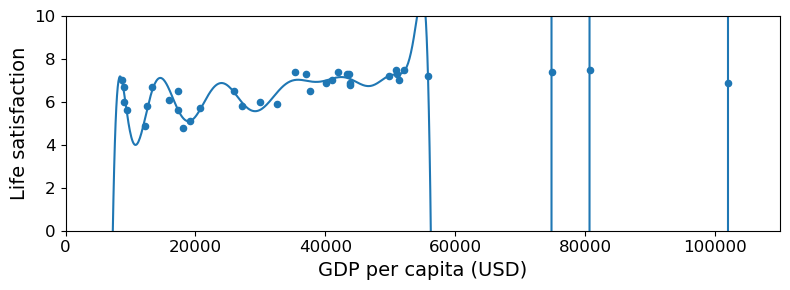

In [61]:
# ============ EXEMPLO DE OVERFITTING (SOBREAJUSTE) ============
# Este código demonstra o que NÃO fazer: criar um modelo muito complexo

# Cria gráfico de dispersão com TODOS os países (incluindo outliers)
full_country_stats.plot(kind='scatter',       # Tipo: scatter plot
                       x="GDP per capita",    # Eixo X: PIB per capita
                       y='Life satisfaction', # Eixo Y: Satisfação de vida
                       figsize=(8,3))         # Tamanho: 8x3 polegadas

# Define limites dos eixos
plt.axis([0, 110000, 0, 10])


# ========== IMPORTAÇÕES PARA MODELO COMPLEXO ==========

from sklearn import preprocessing   # Ferramentas de pré-processamento
from sklearn import pipeline        # Combinar múltiplos passos em um pipeline


# ========== CRIAÇÃO DE UM MODELO EXTREMAMENTE COMPLEXO ==========

# PASSO 1: Transformação Polinomial de GRAU 30 (!!!)
poly = preprocessing.PolynomialFeatures(degree=30, include_bias=False)
# ⚠️ CRÍTICO: degree=30 é EXCESSIVAMENTE ALTO!
# Cria features polinomiais: x, x², x³, x⁴, ..., x³⁰
# include_bias=False → não adiciona termo constante (1)
#
# Exemplo com degree=2:
# X = [10] → [10, 10²] = [10, 100]
#
# Com degree=30:
# X = [10] → [10, 10², 10³, ..., 10³⁰] = 30 features!!!
# Resultado: modelo EXTREMAMENTE flexível (pode criar curvas bizarras)

# PASSO 2: Normalização dos dados
scaler = preprocessing.StandardScaler()
# Padroniza features: (x - média) / desvio_padrão
# Necessário porque x³⁰ tem valores gigantescos
# Evita problemas numéricos na regressão

# PASSO 3: Modelo de Regressão Linear
lin_reg2 = linear_model.LinearRegression()
# Apesar do nome "linear", aplicado a features polinomiais cria modelo NÃO-LINEAR
# Equação: y = θ₀ + θ₁x + θ₂x² + θ₃x³ + ... + θ₃₀x³⁰


# ========== PIPELINE: COMBINA OS 3 PASSOS ==========

# Cria um pipeline que executa os passos em sequência
pipeline_reg = pipeline.Pipeline([
    ('poly', poly),       # 1º: Transforma X em features polinomiais
    ('scal', scaler),     # 2º: Normaliza as features
    ('lin', lin_reg2)     # 3º: Aplica regressão linear
])
# Vantagem: chama fit() uma vez e executa tudo automaticamente

# Treina o pipeline com TODOS os dados (36 países)
pipeline_reg.fit(Xfull, yfull)
# Xfull = PIB per capita de todos os 36 países
# yfull = Satisfação de vida de todos os 36 países
# O modelo vai tentar se ajustar PERFEITAMENTE a todos os pontos


# ========== GERA A CURVA DE PREDIÇÃO ==========

# Cria predições para 1000 pontos entre 0 e 110000
curve = pipeline_reg.predict(X[:, np.newaxis])
# X[:, np.newaxis] converte X de shape (1000,) para (1000, 1)
# Necessário porque o pipeline espera array 2D
# curve = valores de satisfação previstos para cada valor de PIB

# Desenha a curva do modelo polinomial de grau 30
plt.plot(X, curve)
# Esta curva vai ser MUITO SINUOSA e BIZARRA
# Passa muito próximo (ou exatamente) por cada ponto
# ⚠️ OVERFITTING EXTREMO!

# Adiciona rótulo ao eixo X
plt.xlabel("GDP per capita (USD)")

# Salva o gráfico
save_fig('overfitting_model_plot')
# Nome: "gráfico_de_modelo_com_overfitting"

# Exibe o gráfico
plt.show()

In [62]:
# ============ SELEÇÃO DE PAÍSES COM LETRA "W" NO NOME ============

# Seleciona a satisfação de vida dos países cujo nome contém a letra "W"
full_country_stats.loc[[c for c in full_country_stats.index if "W" in c.upper()]]["Life satisfaction"]

# Quebra do código em partes:
#
# 1. [c for c in full_country_stats.index if "W" in c.upper()]
#    ↑ List comprehension que filtra países com "W" no nome
#
# 2. full_country_stats.loc[...]
#    ↑ Seleciona as LINHAS dos países filtrados
#
# 3. ["Life satisfaction"]
#    ↑ Seleciona apenas a COLUNA de satisfação de vida

Country
New Zealand    7.3
Sweden         7.2
Norway         7.4
Switzerland    7.5
Name: Life satisfaction, dtype: float64

In [65]:
# ============ SELEÇÃO DOS PRIMEIROS 5 PAÍSES COM "W" NO NOME (DataFrame PIB) ============

# Seleciona os primeiros 5 países cujo nome contém a letra "W" do DataFrame de PIB
gdp_per_capita.loc[[c for c in gdp_per_capita.index if "W" in c.upper()]].head()

# Quebra do código:
#
# 1. [c for c in gdp_per_capita.index if "W" in c.upper()]
#    ↑ List comprehension: filtra países com "W" (case-insensitive)
#
# 2. gdp_per_capita.loc[...]
#    ↑ Seleciona as LINHAS dos países filtrados
#
# 3. .head()
#    ↑ Retorna apenas as PRIMEIRAS 5 LINHAS (comportamento padrão)

,Subject Descriptor,Units,Scale,Country/Series-specific Notes,GDP per capita,Estimates Start After
Country,,,,,,
Botswana,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",6040.957,2008.0
Kuwait,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",29363.027,2014.0
Malawi,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",354.275,2011.0
New Zealand,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",37044.891,2015.0
Norway,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",74822.106,2015.0


Salvando figura ridge_model_plot


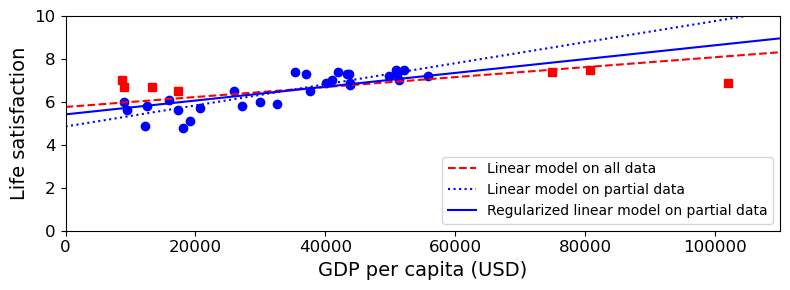

In [66]:
# ============ COMPARAÇÃO DE TRÊS MODELOS: LINEAR, LINEAR COM OUTLIERS E RIDGE (REGULARIZADO) ============

# Cria figura com tamanho específico
plt.figure(figsize=(8,3))

# Define rótulos dos eixos
plt.xlabel("GDP per capita")
plt.ylabel('Life satisfaction')


# ========== PLOTAR OS DADOS: LIMPOS vs OUTLIERS ==========

# Plota os 29 países MANTIDOS (dados limpos) como CÍRCULOS AZUIS
plt.plot(list(sample_data["GDP per capita"]),      # X: PIB dos países limpos
         list(sample_data["Life satisfaction"]),   # Y: Satisfação dos países limpos
         "bo")                                     # "bo" = blue circles (círculos azuis)

# Plota os 7 países REMOVIDOS (outliers) como QUADRADOS VERMELHOS
plt.plot(list(missing_data["GDP per capita"]),     # X: PIB dos outliers
         list(missing_data["Life satisfaction"]),  # Y: Satisfação dos outliers
         "rs")                                     # "rs" = red squares (quadrados vermelhos)


# ========== LINHAS DOS TRÊS MODELOS ==========

# Cria 1000 pontos para desenhar linhas suaves
X = np.linspace(0, 110000, 1000)


# MODELO 1: Regressão Linear com TODOS os dados (incluindo outliers)
plt.plot(X, t0full + t1full * X, "r--", label="Linear model on all data")
# "r--" = red dashed (vermelho tracejado)
# t0full, t1full = parâmetros do modelo treinado com 36 países
# Esta linha é "puxada" pelos outliers extremos


# MODELO 2: Regressão Linear apenas com dados LIMPOS (sem outliers)
plt.plot(X, t0 + t1*X, "b:", label="Linear model on partial data")
# "b:" = blue dotted (azul pontilhado)
# t0, t1 = parâmetros do modelo treinado com 29 países
# Esta linha se ajusta melhor aos dados típicos


# ========== MODELO 3: RIDGE REGRESSION (REGULARIZAÇÃO) ==========

# Cria modelo Ridge com regularização FORTE
ridge = linear_model.Ridge(alpha=10**9.5)
# alpha = parâmetro de regularização (penalidade)
# 10**9.5 ≈ 3,162,277,660 = valor EXTREMAMENTE ALTO!
# ⚠️ Alpha alto = forte regularização = linha mais "conservadora"
#
# Ridge penaliza coeficientes grandes:
# Minimiza: MSE + alpha × (θ₁² + θ₂² + ...)
# Resultado: coeficientes menores, modelo mais simples

# Prepara dados LIMPOS (sem outliers) para treinar Ridge
Xsample = np.c_[sample_data["GDP per capita"]]
# Shape: (29, 1) - apenas os 29 países mantidos

ysample = np.c_[sample_data["Life satisfaction"]]
# Shape: (29, 1) - satisfação dos 29 países

# Treina o modelo Ridge
ridge.fit(Xsample, ysample)
# Com alpha muito alto, Ridge vai "achatar" a linha
# Evita que o modelo seja muito sensível a variações

# Extrai parâmetros do modelo Ridge
t0ridge, t1ridge = ridge.intercept_[0], ridge.coef_[0][0]
# t0ridge = intercepto (com regularização)
# t1ridge = inclinação (MENOR que t1 devido à regularização)

# Plota a linha do modelo Ridge
plt.plot(X, t0ridge + t1ridge * X, "b", label="Regularized linear model on partial data")
# "b" = blue solid (azul sólido)
# Esta linha será mais "achatada" que a linha azul pontilhada


# ========== FINALIZAÇÃO DO GRÁFICO ==========

# Adiciona legenda no canto inferior direito
plt.legend(loc="lower right")

# Define limites dos eixos
plt.axis([0, 110000, 0, 10])

# Rótulo do eixo X (redundante, já foi definido acima)
plt.xlabel("GDP per capita (USD)")

# Salva o gráfico
save_fig('ridge_model_plot')
# Nome: "gráfico_modelo_ridge"

# Exibe o gráfico
plt.show()

# 📊 Conclusão: Comparação de Modelos de Regressão

## 🔍 Análise do Gráfico

### **Dados Visualizados:**
- 🔵 **Círculos azuis:** 29 países (dados limpos, sem outliers)
- 🔴 **Quadrados vermelhos:** 7 países removidos (outliers)

### **Três Modelos Comparados:**

| Modelo | Linha | Inclinação | Observação |
|--------|-------|------------|------------|
| **Linear (parcial)** | 🔵 Azul pontilhada | **Alta** ↗↗ | Melhor ajuste aos dados típicos |
| **Linear (completo)** | 🔴 Vermelha tracejada | **Média** ↗ | Afetado pelos outliers ricos |
| **Ridge (regularizado)** | 🔵 Azul sólida | **Quase zero** → | Regularização extrema (α=10⁹·⁵) |

---

## 💡 Conclusões Principais:

### **1. Impacto dos Outliers** 🎯
```
✅ Modelo Azul Pontilhado (sem outliers):
   • Inclinação mais acentuada
   • Passa bem pelos círculos azuis
   • Representa melhor a relação PIB ↔ Satisfação para países "normais"

❌ Modelo Vermelho Tracejado (com outliers):
   • Inclinação mais suave (achatada)
   • "Puxado para baixo" pelos países ricos à direita
   • Prevê satisfação MENOR que o real para países médios
```

**Motivo:** Os outliers ricos (Luxemburgo, Suíça, Noruega) têm satisfação **relativamente baixa** para seus PIBs elevados (~$60k-$100k), forçando a linha vermelha a descer.

---

### **2. Regularização Extrema (Ridge)** ⚠️
```
O modelo Ridge (linha azul sólida) está praticamente HORIZONTAL!

Equação aproximada: Satisfação ≈ 6.5 (constante)

Isso significa que o modelo está dizendo:
"Não importa o PIB, a satisfação é sempre ~6.5"
```

**Causa:** `alpha=10⁹·⁵` (3 bilhões!) é **absurdamente alto**
- Penaliza fortemente qualquer inclinação
- Resultado: **underfit severo** (modelo ignora os dados)
- Na prática, seria melhor usar α entre 0.1 e 100

---

### **3. Qual Modelo é Melhor?** 🏆

```
🥇 MODELO AZUL PONTILHADO (Linear com dados limpos)
   ✅ Melhor trade-off
   ✅ Remove outliers problemáticos
   ✅ Generaliza bem para países típicos
   ✅ Inclinação realista: mais PIB = mais satisfação

🥈 MODELO VERMELHO TRACEJADO (Linear com todos os dados)
   ⚠️ Afetado por outliers
   ⚠️ Subestima satisfação de países médios
   ⚠️ Mas pode ser útil se outliers forem legítimos

🥉 MODELO AZUL SÓLIDO (Ridge extremo)
   ❌ Regularização excessiva
   ❌ Ignora correlação clara nos dados
   ❌ Exemplo educacional de "overregularization"
```

---

## 📈 Insights Importantes:

### **A. Países Ricos Têm "Rendimentos Decrescentes"**
```
PIB $10k → $30k:  Satisfação sobe de 5.5 para 7.0 (+1.5 pontos)
PIB $30k → $90k:  Satisfação sobe de 7.0 para 7.8 (+0.8 pontos)
```
- Dobrar a riqueza de $10k para $20k tem **grande impacto**
- Dobrar de $50k para $100k tem **impacto menor**
- Isso explica por que outliers ricos "achatam" a linha vermelha

---

### **B. Importância da Limpeza de Dados**
```
Sem remover outliers (linha vermelha):
   • Chipre ($22k) → Predição: 6.2

Com dados limpos (linha azul pontilhada):
   • Chipre ($22k) → Predição: 6.8  ← 0.6 pontos maior!
```
- Remover outliers **melhora predições** para países típicos
- Mas perde-se informação sobre casos extremos

---

### **C. Regularização Deve Ser Balanceada**
```
Alpha Ideal ≈ 0.1 a 100  ← Encontrado via validação cruzada
Alpha = 10⁹·⁵           ← Modelo inútil (muito conservador)
```

---

## 🎯 Recomendação Final:

Para **produção** em um modelo real de predição de satisfação de vida:

1. ✅ **Use o modelo azul pontilhado** (Linear com dados limpos)
2. ✅ Remova outliers extremos (ou trate-os separadamente)
3. ✅ Se usar Ridge, escolha α razoável (0.1-100) via validação cruzada
4. ✅ Considere modelos não-lineares (ex: polinomial grau 2) para capturar rendimentos decrescentes

---

## 📚 Lição Educacional:

Este gráfico ilustra perfeitamente **3 conceitos fundamentais de ML**:

1. **Outliers distorcem modelos** (compare linhas vermelha vs azul pontilhada)
2. **Regularização previne overfitting** (mas em excesso causa underfitting)
3. **Limpeza de dados é crucial** (garbage in = garbage out)

**Moral:** Um modelo simples com dados limpos geralmente supera um modelo complexo com dados sujos! 🚀